M3 CLUSTERING ANALYSIS
Dataset: spotify_complete.csv

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

sns.set_style("whitegrid")


1 LOAD DATASET

In [ ]:


df = pd.read_csv("spotify_complete.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (8947, 19)
   track_id  danceability    energy  acousticness   valence       tempo  \
0         1      0.524724  0.062734      0.449165  0.305175  100.873429   
1         2      0.870429  0.039058      0.845882  0.105507  122.545555   
2         3      0.739196  0.259025      0.432270  0.287306  124.680166   
3         4      0.659195  0.005920      0.475515  0.335935  119.757849   
4         5      0.393611  0.289313      0.845768  0.720471   93.424700   

    loudness  liveness  speechiness    duration_ms    genres  \
0 -12.820209  0.105135     0.026302  415996.583110       pop   
1 -12.734625  0.203157     0.012381  591968.669519       r&b   
2   0.000000  0.199950     0.100861  330889.239458  acoustic   
3  -1.949455  0.148200     0.082974  101491.027075    hiphop   
4 -10.227627  0.006347     0.136194  111375.574618       pop   

   acoustic_electronic_ratio  ratio_fixed  ratio_log  duration_norm  cluster  \
0                   7.159800     7.159800   2.099220     4

2 SELECT RAW AUDIO FEATURES

In [ ]:

features = [
    "danceability",
    "energy",
    "acousticness",
    "valence",
    "tempo",
    "loudness",
    "speechiness",
    "liveness",
    "duration_ms"
]

data = df[features].copy()

3 CREATE DERIVED FEATURE and acoustic_electronic_ratio

In [ ]:


data["acoustic_electronic_ratio"] = (
    df["acousticness"] / (df["energy"] + 1e-6)
)


4 LOG TRANSFORM (fix extreme outliers)

In [ ]:

data["acoustic_electronic_ratio"] = np.log1p(
    data["acoustic_electronic_ratio"]
)


5 STANDARDIZE FEATURES

In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)


6 FIND BEST NUMBER OF CLUSTERS

In [ ]:


k_range = range(2, 7)

sil_scores = []
db_scores = []

for k in k_range:

    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)

    sil_scores.append(sil)
    db_scores.append(db)

print("Silhouette scores:", sil_scores)
print("Davies-Bouldin scores:", db_scores)

Silhouette scores: [np.float64(0.17475567461130767), np.float64(0.09995566678596668), np.float64(0.08639372967515704), np.float64(0.0907142998109692), np.float64(0.09343250557084765)]
Davies-Bouldin scores: [np.float64(1.9954784726903356), np.float64(2.653862334001205), np.float64(2.5907433997409135), np.float64(2.42395212033622), np.float64(2.256593930462726)]


7 PLOT CLUSTER EVALUATION

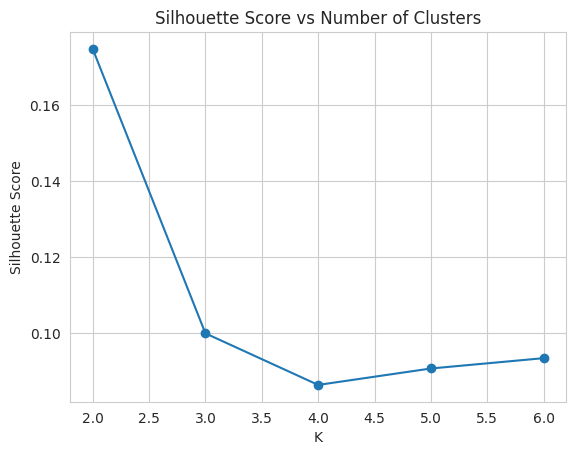

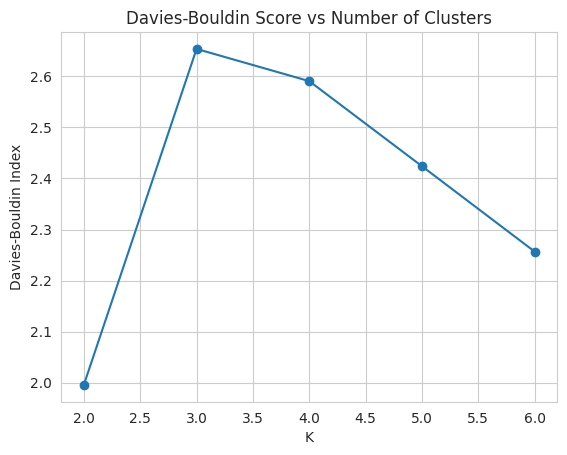

In [ ]:

plt.figure()
plt.plot(k_range, sil_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.savefig("silhouette_plot.png")
plt.show()

plt.figure()
plt.plot(k_range, db_scores, marker='o')
plt.title("Davies-Bouldin Score vs Number of Clusters")
plt.xlabel("K")
plt.ylabel("Davies-Bouldin Index")
plt.savefig("davies_bouldin_plot.png")
plt.show()


8 FINAL KMEANS MODEL

In [ ]:

kmeans = KMeans(n_clusters=2, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

data["cluster"] = clusters

print("\nCluster counts:")
print(data["cluster"].value_counts())


Cluster counts:
cluster
1    7413
0    1534
Name: count, dtype: int64


9 PCA VISUALIZATION

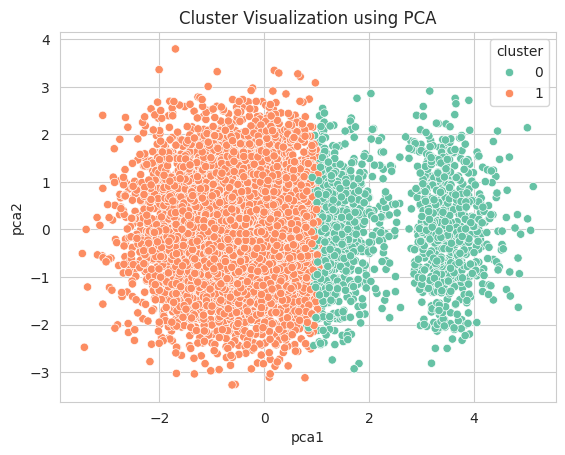

In [ ]:

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

data["pca1"] = pca_result[:, 0]
data["pca2"] = pca_result[:, 1]

plt.figure()

sns.scatterplot(
    x="pca1",
    y="pca2",
    hue="cluster",
    data=data,
    palette="Set2"
)

plt.title("Cluster Visualization using PCA")
plt.savefig("cluster_pca_plot.png")
plt.show()

10 CLUSTER PROFILE

In [ ]:

cluster_profile = data.groupby("cluster").mean()

print("\nCluster Feature Averages:")
print(cluster_profile)



Cluster Feature Averages:
         danceability    energy  acousticness   valence       tempo  loudness  \
cluster                                                                         
0            0.590968  0.056012      0.835314  0.497722  118.143527 -7.217069   
1            0.597454  0.358194      0.584559  0.497172  118.451568 -7.044040   

         speechiness  liveness    duration_ms  acoustic_electronic_ratio  \
cluster                                                                    
0           0.077066  0.147424  214303.721674                   3.445730   
1           0.075313  0.150034  212492.858265                   1.043322   

             pca1      pca2  
cluster                      
0        2.414717 -0.011346  
1       -0.499686  0.002348  


11 DEDUPLICATION EXPERIMENT

In [ ]:

print("\nRunning deduplication experiment...")

if "track_id" in df.columns:
    df_dedup = df.drop_duplicates(subset="track_id")
else:
    df_dedup = df.drop_duplicates()

data_dedup = df_dedup[features].copy()

data_dedup["acoustic_electronic_ratio"] = (
    df_dedup["acousticness"] / (df_dedup["energy"] + 1e-6)
)

data_dedup["acoustic_electronic_ratio"] = np.log1p(
    data_dedup["acoustic_electronic_ratio"]
)

X_dedup = scaler.fit_transform(data_dedup)

model_dedup = KMeans(n_clusters=2, random_state=42)
labels_dedup = model_dedup.fit_predict(X_dedup)

sil_dedup = silhouette_score(X_dedup, labels_dedup)
db_dedup = davies_bouldin_score(X_dedup, labels_dedup)

print("\nOriginal Dataset:")
print("Silhouette:", silhouette_score(X_scaled, clusters))
print("Davies-Bouldin:", davies_bouldin_score(X_scaled, clusters))

print("\nDeduplicated Dataset:")
print("Silhouette:", sil_dedup)
print("Davies-Bouldin:", db_dedup)




Running deduplication experiment...

Original Dataset:
Silhouette: 0.17475567461130767
Davies-Bouldin: 1.9954784726903356

Deduplicated Dataset:
Silhouette: 0.17475567461130767
Davies-Bouldin: 1.9954784726903356
